<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import keras
from keras import layers

inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [2]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,234 (1.42 MB)

 Trainable params: 372,234 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype("float32") / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype("float32") / 255

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(train_images, train_labels, epochs=5, batch_size=64)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9239 - loss: 0.2432
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9781 - loss: 0.0701
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9860 - loss: 0.0461
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9890 - loss: 0.0361
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9912 - loss: 0.0289


In [4]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9893 - loss: 0.0325
Test accuracy: 0.989


In [5]:
# # Downloading a Kaggle dataset in Google Colaboratory
# import kagglehub

# kagglehub.login()

In [6]:
# download_path = kagglehub.competition_download("dogs-vs-cats")

# import zipfile

# with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
#     zip_ref.extractall(".")

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning with Python/Ch8/data'

In [17]:
import os
import shutil
import pathlib

# Path to the directory containing the original dataset
original_dir = pathlib.Path(file_path)

# Directory where we will store our smaller dataset
new_base_dir = pathlib.Path(file_path + "/dogs_vs_cats_small")

In [18]:
def make_subset(subset_name, start_index, end_index):
    for category in ("Cat", "Dog"):
        dir = new_base_dir / subset_name / category.lower()
        os.makedirs(dir, exist_ok=True)

        fnames = [f"{i}.jpg" for i in range(start_index, end_index)]

        for fname in fnames:
            shutil.copyfile(
                src=original_dir / category / fname,
                dst=dir / fname
            )

In [20]:
# # Creates the training subset with the first 1000 images of each category
# make_subset("train", start_index=0, end_index=1000)

# # Creates the validation subset with the next 500 images of each category
# make_subset("validation", start_index=1000, end_index=1500)

# # Creates the test subset with the next 1000 images of each category
# make_subset("test", start_index=1500, end_index=2500)

In [21]:
import keras
from keras import layers

# The model expects RGB images of size 180 x 180.
inputs = keras.Input(shape=(180, 180, 3))

# Rescales inputs to the [0, 1] range by dividing them by 255
x = layers.Rescaling(1.0 / 255)(inputs)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)

# Flattens the 3D activations with shape (height, width, 512) into 1D
# activations with shape (512,) by averaging with them over spatial dimensions
x = layers.GlobalAveragePooling2D()(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [22]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [40]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1998 files belonging to 2 classes.


In [25]:
import numpy as np
import tensorflow as tf

random_numbers = np.random.normal(size=(1000, 16))

# The from_tensor_slices() class method can be used to create a Dataset
# from a NumPy array or a tuple or dict of NumPy arrays.
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

In [26]:
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [27]:
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [28]:
reshaped_dataset = dataset.map(
    lambda x: tf.reshape(x, (4, 4)),
    num_parallel_calls=8
)

In [29]:
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


In [30]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [33]:
from pathlib import Path

train_dir = new_base_dir / "train"

empty_files = [
    path for path in train_dir.rglob("*")
    if path.is_file() and path.stat().st_size == 0
]

print(f"Empty files: {len(empty_files)}")

for path in empty_files:
    print(path)

Empty files: 0


In [34]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 403ms/step - accuracy: 0.4957 - loss: 0.6943 - val_accuracy: 0.5140 - val_loss: 0.6919
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.5653 - loss: 0.6841 - val_accuracy: 0.5780 - val_loss: 0.7079
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 293ms/step - accuracy: 0.5573 - loss: 0.6853 - val_accuracy: 0.5940 - val_loss: 0.6599
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.6058 - loss: 0.6598 - val_accuracy: 0.6140 - val_loss: 0.6557
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.6103 - loss: 0.6474 - val_accuracy: 0.6770 - val_loss: 0.6103
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.6513 - loss: 0.6222 - val_accuracy: 0.6780 - val_loss: 0.6150
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - accuracy: 0.6683 - loss: 0.6107 - val_accuracy: 0.6780 - val_loss: 0.6100
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 0.6768 - loss: 0.5985 - val_accuracy:

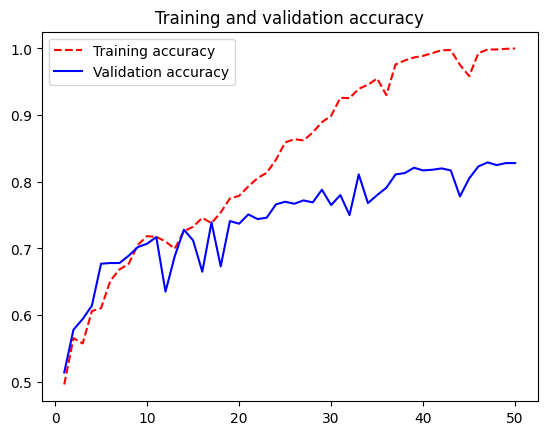

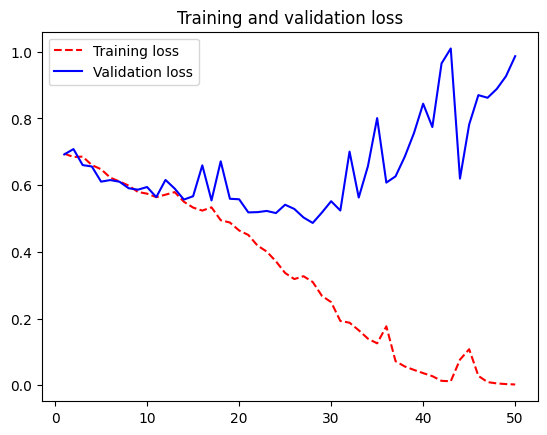

In [35]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [39]:
import tensorflow as tf
from pathlib import Path

test_dir = new_base_dir / "test"

bad_files = []

for path in test_dir.rglob("*.jpg"):
    try:
        image_bytes = tf.io.read_file(str(path))
        image = tf.io.decode_image(image_bytes, expand_animations=False)

        channels = image.shape[-1]

        if channels not in (1, 3, 4):
            bad_files.append((path, channels))

    except Exception as e:
        bad_files.append((path, str(e)))

print(f"Bad images: {len(bad_files)}")

for item in bad_files:
    print(item)

Bad images: 0


In [41]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.7858 - loss: 0.4626
Test accuracy: 0.786


In [44]:
# Using data augmentation
# Define the transformations to apply as a list
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

# Creates a function that applies them sequentially
def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)

    return images, targets

# Maps this function into the dataset
augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)

# Enables prefecching of batches on GPU memory; important for best performance
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

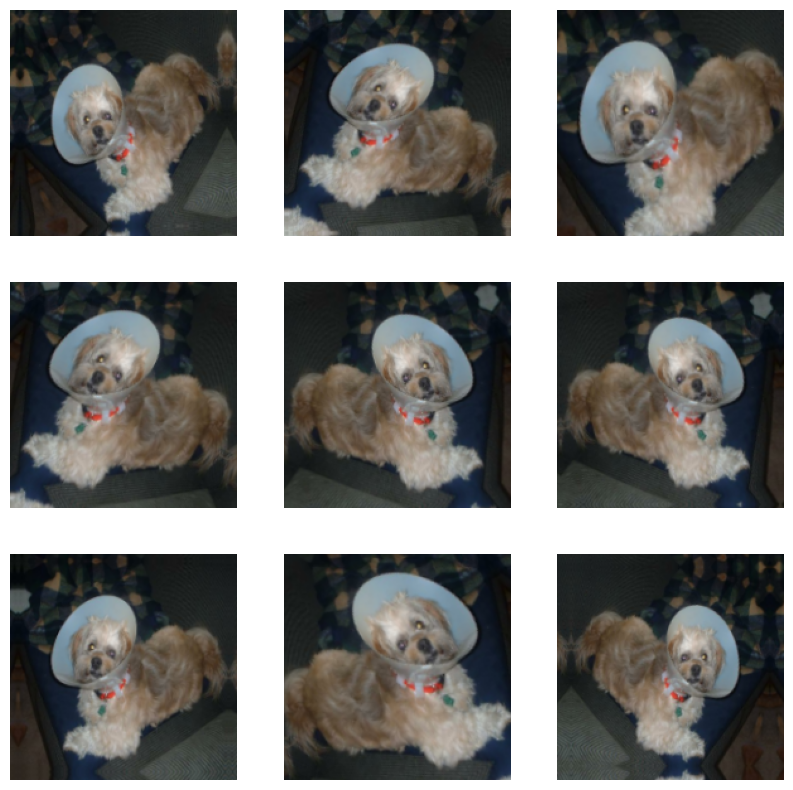

In [46]:
plt.figure(figsize=(10, 10))

# You can use take(N) to only sample N batches from the dataset.
# This is equivalent to inserting a break in the loop after the Nth batch.
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)

        # Displays the first image in the output batch.
        # For each of the nine iterations, this is a differnet augmentation of the same image.
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

In [50]:
inputs = keras.Input(shape=(180, 180, 3))

x = layers.Rescaling(1.0 / 255)(inputs)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [51]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,

    # Since we expect the model to overfit slower, we train for more epochs.
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 522ms/step - accuracy: 0.5063 - loss: 0.6944 - val_accuracy: 0.5010 - val_loss: 0.6908
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 633ms/step - accuracy: 0.5103 - loss: 0.6918 - val_accuracy: 0.5780 - val_loss: 0.6841
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 551ms/step - accuracy: 0.5148 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 542ms/step - accuracy: 0.4947 - loss: 0.6949 - val_accuracy: 0.5150 - val_loss: 0.6919
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 537ms/step - accuracy: 0.5053 - loss: 0.6914 - val_accuracy: 0.5500 - val_loss: 0.6917
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 530ms/step - accuracy: 0.5053 - loss: 0.6930 - val_accuracy: 0.5010 - val_loss: 0.6923
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 551ms/step - accuracy: 0.5203 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 525ms/step - accuracy: 0.5093 - loss: 0.6912 - 

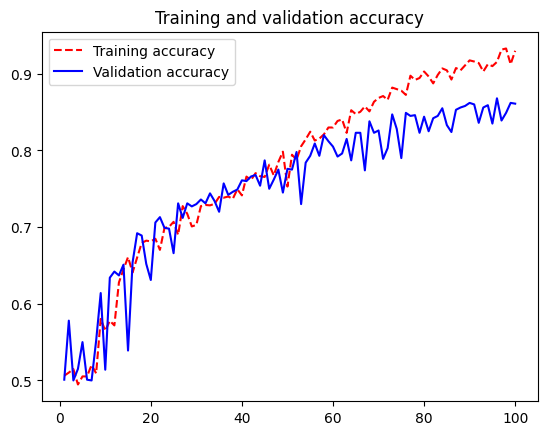

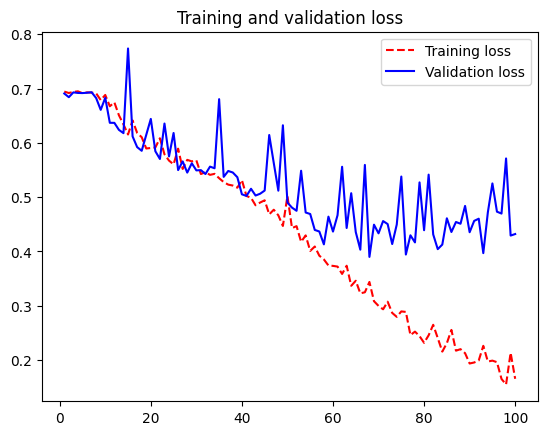

In [52]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [55]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 171ms/step - accuracy: 0.8208 - loss: 0.4210
Test accuracy: 0.821


In [56]:
# Download the saved file
from google.colab import files

files.download("convnet_from_scratch_with_augmentation.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
# Using a pretrained model

In [58]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

100%|██████████| 1.79k/1.79k [00:00<00:00, 7.18MB/s]


100%|██████████| 79.9M/79.9M [00:02<00:00, 40.0MB/s]


In [59]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

In [60]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []

    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)

    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [61]:
train_features.shape

(1999, 6, 6, 2048)

In [62]:
inputs = keras.Input(shape=(6, 6, 2048))

# Averages spatial dimensions to flatten the feature map
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9610 - loss: 0.1019 - val_accuracy: 0.9850 - val_loss: 0.0506
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9850 - loss: 0.0365 - val_accuracy: 0.9870 - val_loss: 0.0465
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9925 - loss: 0.0189 - val_accuracy: 0.9770 - val_loss: 0.0646
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.9850 - val_loss: 0.0534
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.9830 - val_loss: 0.0632
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9850 - val_loss: 0.0604
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9860 - val_loss: 0.0579
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 9.7266e-04 - val_accuracy: 0.9860

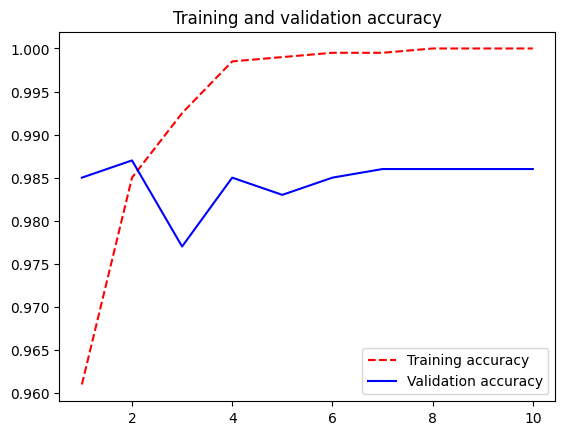

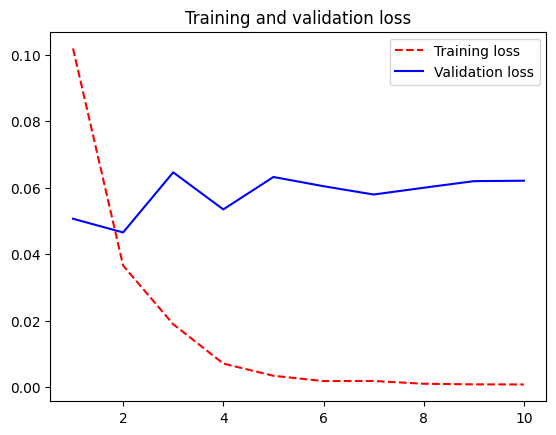

In [63]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")

plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [64]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9840 - loss: 0.0512
Test accuracy: 0.984


In [66]:
import keras_hub

# Setting trainable to False empties the list of trainable weights of the layer or model.
conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [67]:
conv_base.trainable = True

# The number of trainable weights before freezing the conv base
len(conv_base.trainable_weights)

154

In [68]:
conv_base.trainable = False

# The number of trainable weights after freezing the conv base
len(conv_base.trainable_weights)

0

In [69]:
# Create a new model that chains together our frozen convolutional base and a dense classifier
inputs = keras.Input(shape=(180, 180, 3))

x = preprocessor(inputs)
x = conv_base(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [70]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8939 - loss: 0.3331 - val_accuracy: 0.9850 - val_loss: 0.0542
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 613ms/step - accuracy: 0.9625 - loss: 0.1095 - val_accuracy: 0.9830 - val_loss: 0.0487
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 629ms/step - accuracy: 0.9715 - loss: 0.0720 - val_accuracy: 0.9880 - val_loss: 0.0489
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 584ms/step - accuracy: 0.9725 - loss: 0.0723 - val_accuracy: 0.9820 - val_loss: 0.0600
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 608ms/step - accuracy: 0.9775 - loss: 0.0647 - val_accuracy: 0.9820 - val_loss: 0.0517
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 568ms/step - accuracy: 0.9755 - loss: 0.0574 - val_accuracy: 0.9830 - val_loss: 0.0536
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 595ms/step - accuracy: 0.9745 - loss: 0.0721 - val_accuracy: 0.9830 - val_loss: 0.0634
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 574ms/step - accuracy: 0.9745 - loss: 0.0646 - val_accurac

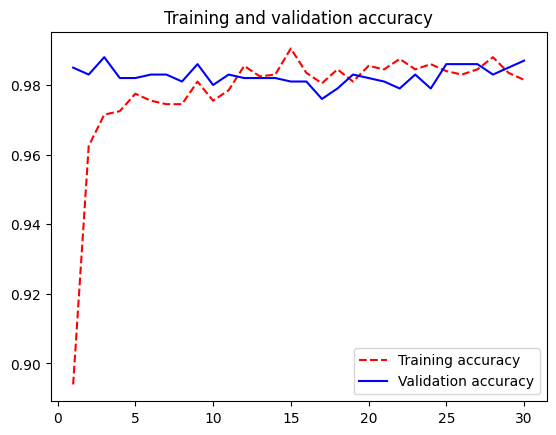

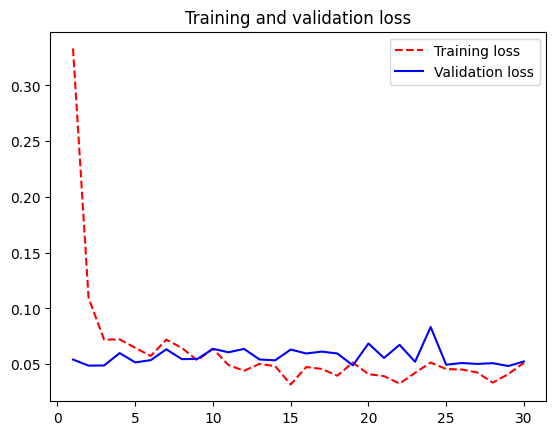

In [71]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")

plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [73]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 336ms/step - accuracy: 0.9870 - loss: 0.0526
Test accuracy: 0.987


In [74]:
# Fine-tuning a pretrained model

In [75]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [76]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9880 - loss: 0.0311 - val_accuracy: 0.9850 - val_loss: 0.0496
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 887ms/step - accuracy: 0.9895 - loss: 0.0329 - val_accuracy: 0.9840 - val_loss: 0.0476
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 699ms/step - accuracy: 0.9895 - loss: 0.0286 - val_accuracy: 0.9840 - val_loss: 0.0466
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 637ms/step - accuracy: 0.9875 - loss: 0.0395 - val_accuracy: 0.9850 - val_loss: 0.0464
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 676ms/step - accuracy: 0.9855 - loss: 0.0417 - val_accuracy: 0.9840 - val_loss: 0.0476
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 608ms/step - accuracy: 0.9890 - loss: 0.0309 - val_accuracy: 0.9840 - val_loss: 0.0471
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 639ms/step - accuracy: 0.9895 - loss: 0.0288 - val_accuracy: 0.9850 - val_loss: 0.0463
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 610ms/step - accuracy: 0.9895 - loss: 0.0349 - val_accurac

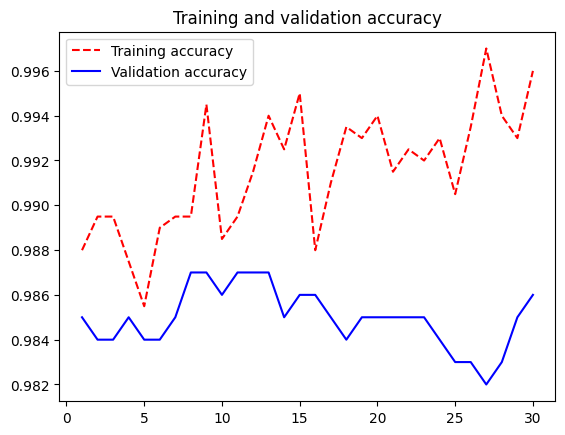

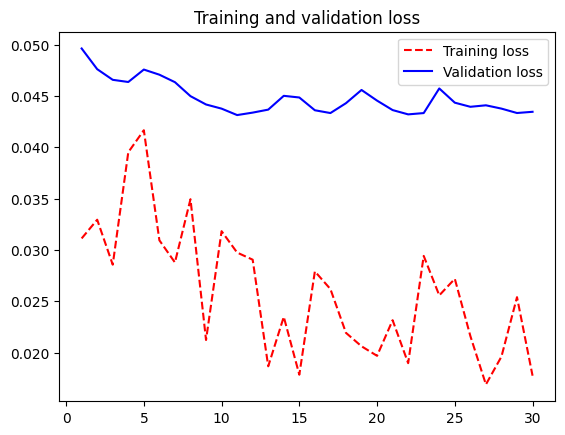

In [77]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")

plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [79]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 333ms/step - accuracy: 0.9865 - loss: 0.0465
Test accuracy: 0.986
